# LIBRARIES

In [2]:
import pandas as pd
import numpy as np

# Load CSV Files

In [3]:
train_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\train.csv")
val_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\val.csv")
test_df = pd.read_csv("C:\\Users\\Neel Arora\\Downloads\\iitm-dl18-pa3\\test.csv")

In [4]:
train_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
1,1,0,0,0,0,0,1,0,0,0,...,114,130,76,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,3
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
val_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783,label
0,55000,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,55001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
2,55002,0,0,0,0,0,0,0,0,0,...,176,195,144,0,0,0,0,0,0,0
3,55003,0,0,0,0,0,0,0,6,88,...,0,0,71,123,88,20,0,0,0,6
4,55004,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [6]:
test_df.head()

,id,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat774,feat775,feat776,feat777,feat778,feat779,feat780,feat781,feat782,feat783
0,0,0,0,0,0,0,0,1,1,2,...,2,0,0,60,36,24,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,123,97,0,0
2,2,0,0,0,0,0,0,0,0,0,...,2,1,0,0,115,150,47,0,0,0
3,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,144,0,0,0,0,0,0,0,0,0


In [7]:
print('train_df.shape:', train_df.shape, 
      'val_df.shape:', val_df.shape, 
      'test_df.shape:', test_df.shape)

train_df.shape: (55000, 786) val_df.shape: (5000, 786) test_df.shape: (10000, 785)


# Separate Labels And Features

In [8]:
# train.csv and val.csv contains labels

x_train = train_df.drop(["id", "label"], axis=1).values
y_train = train_df["label"].values

x_val = val_df.drop(["id", "label"], axis=1).values
y_val = val_df["label"].values

print("Fixed x_train shape:", x_train.shape)
print("Fixed x_val shape:", x_val.shape)

Fixed x_train shape: (55000, 784)
Fixed x_val shape: (5000, 784)


In [9]:
# test.csv does not contain labels

x_test = test_df.drop("id", axis=1).values

# Normalize pixel values
# Convert from 0-255 -> 0-1

In [10]:
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape 784 -> 28 * 28 * 1

In [11]:
x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Visualizing Sample Training Images 
# Now that images are reshaped to 28×28,
# let's visualize some training examples.

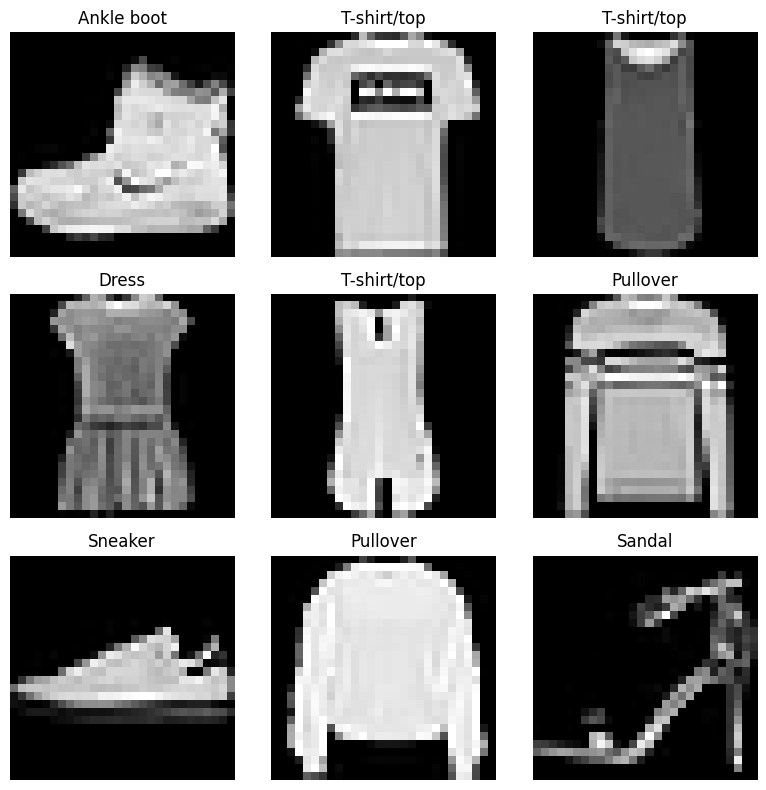

In [12]:
import matplotlib.pyplot as plt

# Fashion-MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    
    image = x_train[i].reshape(28,28)
    label = y_train[i]
    
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Convert grayscale → RGB
# Required because CONV1 expects 3 channels

In [13]:
x_train = np.repeat(x_train,3,axis=-1)
x_val = np.repeat(x_val,3, axis=-1)
x_test = np.repeat(x_test,3,axis=-1)

print("Final x_train shape:", x_train.shape)

Final x_train shape: (55000, 28, 28, 3)


# Model Architecture

Now we implement the CNN architecture exactly as specified in the assignment:

- All convolution filters are 3×3
- Stride = 1
- Padding = 1 (same padding)
- ReLU activations
- Batch Normalization before Softmax
- Early stopping will be added during training

In [14]:
# BUILD CNN ARCHITECTURE (AS PER ASSIGNMENT)
import tensorflow as tf
from tensorflow.keras import layers ,models ,initializers

# Use He initialization (recommended for ReLU)
initializer = initializers.HeNormal()

model = models.Sequential()

In [15]:
# CONV1: 3 → 64
# Output: 64 × 28 × 28

model.add(layers.Conv2D(
    64, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer,
    input_shape=(28,28,3)
))

c:\python-envs\ml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# POOL1 → 64 × 14 × 14

model.add(layers.MaxPooling2D((2,2)))

In [17]:
# CONV2: 64 → 128
# Output: 128 × 14 × 14

model.add(layers.Convolution2D(
          128, (3,3),
          strides=1,
          padding="same",
          activation="relu",
          kernel_initializer=initializer
))

In [18]:
# POOL2 → 128 × 7 × 7

model.add(layers.MaxPooling2D((2,2)))

In [19]:
# CONV3: 128 → 256
# Output: 256 × 7 × 7

model.add(layers.Convolution2D(
    256, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer
))

In [20]:
# CONV4: 256 → 256
# Output: 256 × 7 × 7

model.add(layers.Convolution2D(
    256, (3,3),
    strides=1,
    padding="same",
    activation="relu",
    kernel_initializer=initializer
))

In [21]:
# POOL3 → 256 × 3 × 3

model.add(layers.MaxPooling2D((2,2)))

In [22]:
# Flatten → 2304

model.add(layers.Flatten())

In [23]:
# FC1: 2304 → 1024

model.add(layers.Dense(
    1024, 
    activation="relu"
))

model.add(layers.Dropout(0.5)) # reduce overfitting

In [24]:
# FC2: 1024 → 1024

model.add(layers.Dense(
    1024,
    activation="relu"
))

model.add(layers.Dropout(0.5))

In [25]:
# BatchNorm before Softmax

model.add(layers.BatchNormalization())

In [26]:
# Softmax Layer: 1024 → 10

model.add(layers.Dense(
    10,
    activation="softmax"
))

In [27]:
# Show model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,162 (16.73 MB)

 Trainable params: 4,383,114 (16.72 MB)

 Non-trainable params: 2,048 (8.00 KB)

# Training Details

The model is trained using:

- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 64
- Weight Initialization: He Normal
- Early Stopping: Patience = 5
- Loss Function: Sparse Categorical Crossentropy

We monitor validation loss to prevent overfitting.

In [28]:
# COMPILE AND TRAIN THE MODEL

# Import optimizer
import tensorflow as tf

In [29]:
# Learning rate
learning_rate = 0.001

In [30]:
# compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
# Early stopping (Patience = 5 as required)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [32]:
# Train model

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 87s 98ms/step - accuracy: 0.7827 - loss: 0.6090 - val_accuracy: 0.8812 - val_loss: 0.3180
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 98ms/step - accuracy: 0.8898 - loss: 0.3047 - val_accuracy: 0.9084 - val_loss: 0.2570
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 98ms/step - accuracy: 0.9095 - loss: 0.2498 - val_accuracy: 0.9110 - val_loss: 0.2457
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.9209 - loss: 0.2180 - val_accuracy: 0.9118 - val_loss: 0.2603
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 91s 106ms/step - accuracy: 0.9313 - loss: 0.1937 - val_accuracy: 0.9214 - val_loss: 0.2274
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 88s 103ms/step - accuracy: 0.9373 - loss: 0.1723 - val_accuracy: 0.9218 - val_loss: 0.2178
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 86s 100ms/step - accuracy: 0.9448 - loss: 0.1510 - val_accuracy: 0.9124 - val_loss: 0.2321
Epoch 8/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 84s 98ms/step - accuracy: 0.9519 - loss: 0.1325

# EXTRACT TRAINING INFORMATION FOR REPORT

In [33]:
# Total epochs actually trained
total_epochs_trained = len(history.history["loss"])

# Best validation accuracy
best_val_accuracy = max(history.history["val_accuracy"])

print("Total Epochs Trained:", total_epochs_trained)
print("Best Validation Accuracy:", best_val_accuracy)

Total Epochs Trained: 11
Best Validation Accuracy: 0.9291999936103821


# Learning Curve

We plot the training loss and validation loss over epochs.

This helps us analyze:
- Model convergence
- Overfitting behavior
- When early stopping was triggered

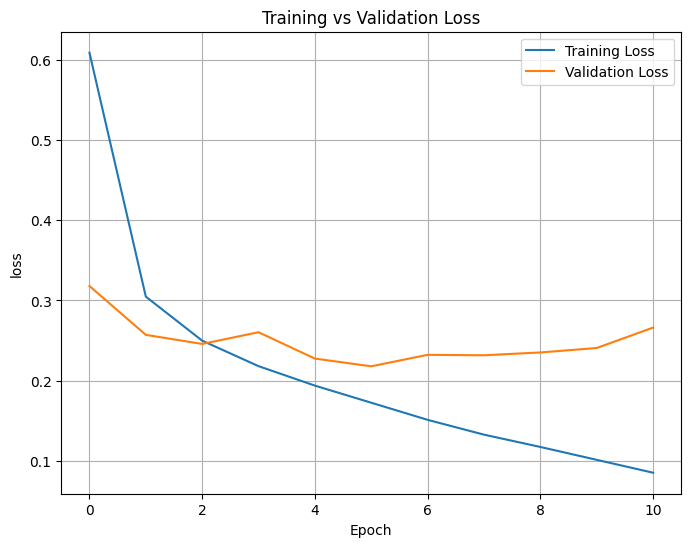

In [34]:
# PLOT LEARNING CURVE

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Training Loss
plt.plot(history.history["loss"], label="Training Loss")

# Validation Loss
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


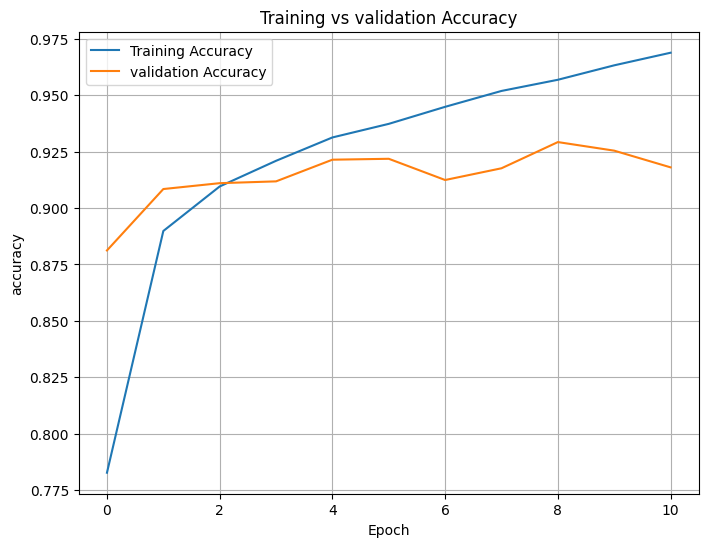

In [35]:
# Plot Accuracy Curve

plt.figure(figsize=(8,6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Test Performance

Since the test dataset does not contain labels, 
we evaluate performance in two ways:

1. Validation Accuracy (local evaluation)
2. Kaggle Leaderboard Score (test accuracy)

In [ ]:
# VALIDATION PERFORMANCE

val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=1)

print("Validation Accuracy:", val_accuracy)
print("Validation Loss:", val_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9218 - loss: 0.2178
Validation Accuracy: 0.9218000173568726
Validation Loss: 0.21780256927013397


In [39]:
# GENERATE KAGGLE SUBMISSION FILE

# Predict on test set
predictions = model.predict(x_test)

# Convert probabilities to class labels
pred_labels = np.argmax(predictions, axis=1)

# Create submission file using id column
submission = test_df[["id"]].copy()
submission["label"] = pred_labels

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
submission.csv created successfully!


# Parameter Count

We compute:

- Total number of parameters in the network
- Parameters in convolutional layers
- Parameters in fully connected layers

This helps analyze model complexity.

In [41]:
# PARAMETER COUNT

total_params = model.count_params()

conv_params = 0
fc_params = 0

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_params += layer.count_params()
    if isinstance(layer, tf.keras.layers.Dense):
        fc_params += layer.count_params()

print("Total Parameters:", total_params)
print("Convolution Layer Parameters:", conv_params)
print("fully Connected Layer Parameters:", fc_params)

Total Parameters: 4385162
Convolution Layer Parameters: 960896
fully Connected Layer Parameters: 3420170


# Neuron Count

We compute the total number of neurons in:

- Convolutional layers
- Fully connected layers

A neuron corresponds to one activation value in the network.

In [42]:
# NEURON COUNT

# Conv layer neurons
conv1_neurons = 64*28*28
conv2_neurons = 128*14*14
conv3_neurons = 256*7*7
conv4_neurons = 256*7*7

total_conv_neurons = conv1_neurons + conv2_neurons + conv3_neurons + conv4_neurons

# Fully connected neurons
fc1_neurons = 1024
fc2_neurons = 1024
softmax_neurons = 10

total_fc_neurons = fc1_neurons + fc2_neurons + softmax_neurons 

print("Total Conv Neurons:", total_conv_neurons)
print("Total FC Neurons:", total_fc_neurons)

Total Conv Neurons: 100352
Total FC Neurons: 2058


## Neuron Analysis

Total neurons in convolutional layers: 100,352  
Total neurons in fully connected layers: 2,058  

Although convolutional layers contain many neurons due to spatial feature maps, 
they have fewer parameters because of weight sharing.

Fully connected layers contain fewer neurons but a significantly larger number of parameters 
since each neuron connects to all neurons from the previous layer.

# Filter Visualization

We visualize the 64 filters from the first convolutional layer.
Each filter is of size 3×3 and operates across 3 channels.

filter shape: (3, 3, 3, 64)


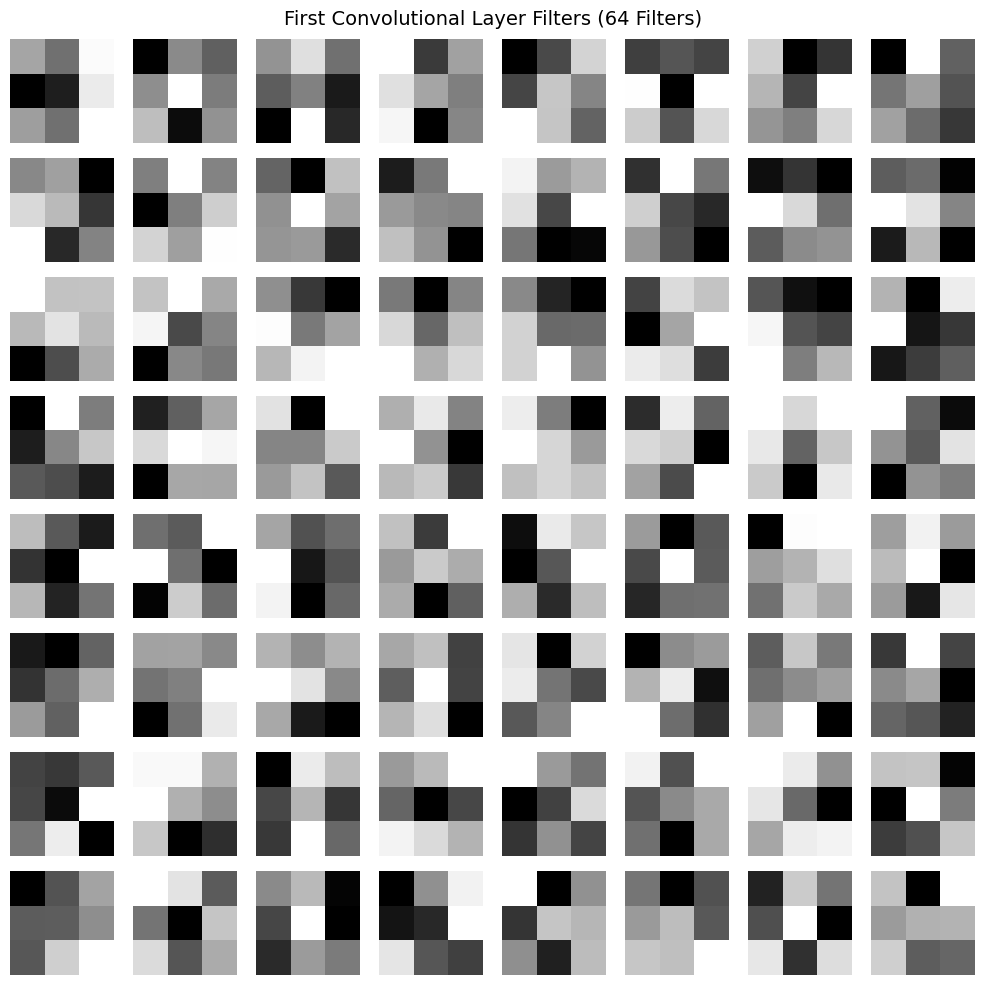

In [44]:
# VISUALIZE FIRST CONV LAYER FILTERS

# Get weights from first Conv layer
filters, biases = model.layers[0].get_weights()

print("filter shape:", filters.shape)
# Expected: (3, 3, 3, 64)

# Normalize filters for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# Plot 64 filters in 8x8 grid
plt.figure(figsize=(10,10))

for i in range(64):
    plt.subplot(8,8,i+1)

    # Average across RGB channels to display as grayscale
    filter_img = np.mean(filters[:,:,:,i], axis=-1)

    plt.imshow(filter_img, cmap="gray")
    plt.axis("off") 

plt.suptitle("First Convolutional Layer Filters (64 Filters)", fontsize=14)
plt.tight_layout()
plt.show()